## Importing required modules

In [1]:
# For handling and manipulating dataset
import pandas as pd
import seaborn as sns

# For splitting dataset
from sklearn.model_selection import train_test_split

# For Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding, SpatialDropout1D
from tensorflow.keras.optimizers import RMSprop
import keras

# For text processing
import re
import nltk
import string
from nltk.corpus import stopwords

/home/fy-g15/Documents/MUN/S11/COMP 4750/NLP-Hate-Speech-Detector/env/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde
2025-11-30 00:13:04.092590: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Optimizing hardware (Only if using Nvidia GPUs)

### Enables Dynamic Memory Allocation (For Nvidia GPUs)

In [2]:
# This prevents TensorFlow from allocating all gpu memory instantly (Prevents crash)

gpus = tf.config.list_physical_devices('GPU')
try:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ Enabled memory growth")
except RuntimeError as e:
    print(e)

✅ Enabled memory growth


### Enable Mixed Precision (Crucial for NLP)

In [3]:
# This makes models run upto 3x faster and use 50% less RAM by using 16-bit math

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("✅ Enabled mixed precision")

✅ Enabled mixed precision


## Importing the hate speech dataset (Balanced dataset)

In [4]:
df1 = pd.read_csv("data/HateSpeechDatasetBalanced.csv")

In [5]:
df1.head()

,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1


## Importing hate speech dataset containing emoji (Balanced dataset)

In [6]:
df2 = pd.read_csv("data/EmojiHate.csv")

In [7]:
df2.head()

,entry_id,text,type,target,round.base,round.set,set,split,label_gold,matched_text,matched_id
0,0,I would love to 🔪 some 👳🏾,threateninglanguage,"['asi.south', 'arab', 'mus']",5,5a,original,train,1,I would love to 👏🏽 some 👳🏾,1
1,2,I would love to 🔪 some 👨🏿,threateninglanguage,['bla'],5,5a,original,train,1,I would love to 🔪some🦊,3
2,3,I would love to 🔪some🦊,none,['none'],5,5b,perturbation,train,0,I would love to 🔪 some 👨🏿,2
3,5,👳🏽 make me 🤢,derogation,"['mus', 'asi.south']",5,5b,perturbation,train,1,🐀 make me 🤢,4
4,6,literally all 👨🏿 men act like gentlemen,none,['none'],5,5b,perturbation,train,0,literally all 👨🏿 men act like hooligans,7


## Cleaning emoji dataset

In [8]:
# Checking if there are any empty values

df2.isnull().sum()

entry_id        0
text            0
type            0
target          0
round.base      0
round.set       0
set             0
split           0
label_gold      0
matched_text    0
matched_id      0
dtype: int64

In [9]:
# Dropping unnecessary fields from emoji dataset

unnecessary_fields = ["entry_id", "type", "target", "round.base", "round.set", "set", "split", "matched_text", "matched_id"]
df2.drop(columns = unnecessary_fields, axis= 1, inplace = True)

In [10]:
# Renaming fields to match df

df2.rename(columns = {"text":"Content", "label_gold":"Label"}, inplace = True)

In [11]:
df2.head()

,Content,Label
0,I would love to 🔪 some 👳🏾,1
1,I would love to 🔪 some 👨🏿,1
2,I would love to 🔪some🦊,0
3,👳🏽 make me 🤢,1
4,literally all 👨🏿 men act like gentlemen,0


## Merging both datasets to one

In [12]:
df = pd.concat([df1, df2], axis = 0, ignore_index=True)

In [13]:
df

,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1
...,...,...
730842,Hell is hot 🔥🔥🔥🔥 and all you fucking woman are...,1
730843,Hell is hot 🔥🔥🔥🔥 and you are not!,0
730844,just let the refugees in 😤😤😤,0
730845,just DON'T let the refugees in then 😤😤😤,1


## Visualizing the dataset

/tmp/ipykernel_7864/1636068153.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df1, palette="Set2")


<Axes: xlabel='Label', ylabel='count'>

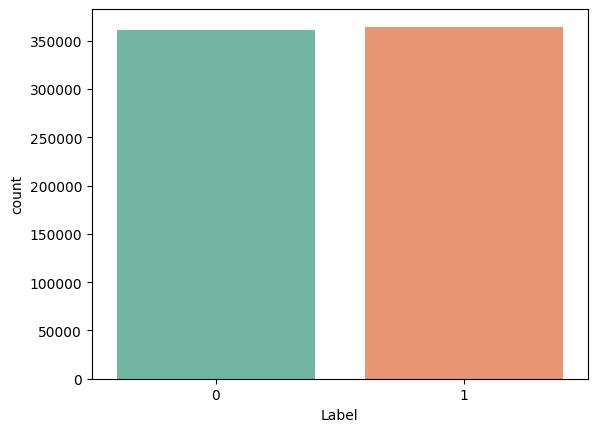

In [14]:
sns.countplot(x='Label', data=df1, palette="Set2")

/tmp/ipykernel_7864/2683709059.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df2, palette="Paired")


<Axes: xlabel='Label', ylabel='count'>

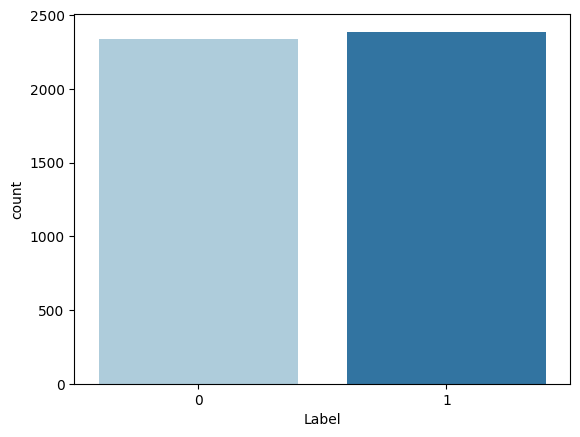

In [15]:
sns.countplot(x='Label', data=df2, palette="Paired")

### '0' means No Hate and '1' means Hate

## Setting up descriptive and target feature for training

In [16]:
x = df['Content']   # Descriptive Feature
y = df['Label']   # Target Feature

### Splitting the data into train and test sets

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 23)

print(len(x_train),len(y_train))
print(len(x_test),len(y_test))

548135 548135
182712 182712


## Feature engineering

In [18]:
max_words = 50000   # Maximum number of unique words (Assumed value)
max_len = 300   # Maximum length of sentence

tokenizer = Tokenizer(num_words = max_words)   # Encodes words to numeric values
tokenizer.fit_on_texts(x_train)

sequences = tokenizer.texts_to_sequences(x_train)   # Converts words to sequence of integers
sequences_matrix = pad_sequences(sequences,maxlen=max_len)   # Pads shorter sequences with 0 so all inputs are exactly 300 tokens long

In [19]:
sequences_matrix

array([[   0,    0,    0, ...,  689,    1,  400],
       [   0,    0,    0, ...,  262,   29,    3],
       [   0,    0,    0, ...,  925,  471, 6281],
       ...,
       [   0,    0,    0, ...,    0,  444,   56],
       [   0,    0,    0, ...,  641,    6,   84],
       [   0,    0,    0, ...,    4,  663, 1562]],
      shape=(548135, 300), dtype=int32)

## Creating model architecture

In [20]:
model = Sequential()

# Maps each word index to a vector (model learns words relationships)
model.add(Embedding(max_words,100,input_length=max_len))

# Helps prevent overfitting by ignoring neurons randomly
model.add(SpatialDropout1D(0.2))

# Long-short term memory (LSTM) is the heart of our model. It learns sequential patterns in the text
model.add(LSTM(100,dropout=0.2,recurrent_dropout=0.2))

# Binary output of 0 and 1. 0 means no hate and 1 means hate
model.add(Dense(1,activation='sigmoid'))

# Builds the model explicitly since we are using the new version of Keras
model.build(input_shape=(None, max_len))
model.summary()

/home/fy-g15/Documents/MUN/S11/COMP 4750/NLP-Hate-Speech-Detector/env/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1764474205.659328    7864 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2128 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,080,501 (19.38 MB)

 Trainable params: 5,080,501 (19.38 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

In [22]:
# starting model training
history = model.fit(sequences_matrix,y_train,batch_size=128,epochs = 1,validation_split=0.2)

3426/3426 ━━━━━━━━━━━━━━━━━━━━ 1315s 383ms/step - accuracy: 0.7980 - loss: 0.4325 - val_accuracy: 0.8206 - val_loss: 0.3922


In [23]:
test_sequences = tokenizer.texts_to_sequences(x_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len)

In [24]:
test_sequences_matrix

array([[    0,     0,     0, ...,  2829,    36, 17858],
       [    0,     0,     0, ...,  2090,     3, 10783],
       [    0,     0,     0, ...,    18,   174,  4016],
       ...,
       [    0,     0,     0, ...,   192,   151,     4],
       [    0,     0,     0, ...,     4,  1998,   170],
       [    0,     0,     0, ...,    37,  3477,  2301]],
      shape=(182712, 300), dtype=int32)

In [25]:
# Model evaluation
accr = model.evaluate(test_sequences_matrix,y_test)

5710/5710 ━━━━━━━━━━━━━━━━━━━━ 493s 86ms/step - accuracy: 0.8217 - loss: 0.3907


In [26]:
lstm_prediction = model.predict(test_sequences_matrix)

5710/5710 ━━━━━━━━━━━━━━━━━━━━ 492s 86ms/step


In [27]:
res = []
for prediction in lstm_prediction:
    if prediction[0] < 0.5:
        res.append(0)
    else:
        res.append(1)

In [28]:
from sklearn.metrics import confusion_matrix

In [29]:
print(confusion_matrix(y_test,res))

[[70384 20618]
 [11972 79738]]


In [30]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [31]:
# Let's save the model.
model.save("model.h5")

In [32]:
# Downloads the stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/fy-g15/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
# Let's apply stemming and stopwords on the data
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

In [34]:
load_model=keras.models.load_model("model.h5")
with open('tokenizer.pickle', 'rb') as handle:
    load_tokenizer = pickle.load(handle)

In [62]:
test = "Bugger off!"

def clean_text(text):
    """
    Text cleaning function. Removes URLs, punctuations, numbers and stopwords. Also applies stemming to reduce words to their root form.
    """
    
    print(text)
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    print(text)

    # Filters out common words that don't add meaning (for e.g. articles)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)

    # Reduces words to root form (for e.g. Running -> Run)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

test=[clean_text(test)]
print(test)

seq = load_tokenizer.texts_to_sequences(test)
padded = pad_sequences(seq, maxlen=300)
print(seq)

pred = load_model.predict(padded)

print("pred", pred)
if pred<0.5:
    print("no hate")
else:
    print("hate and abusive")

Bugger off!
bugger off
['bugger']
[[8893]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
pred [[0.583]]
hate and abusive
